# lrdata to MuData

### Load packages

In [1]:
from pathlib import Path
import scanpy as sc
import squidpy as sq
import liana as li
import pandas as pd
import os

/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in futur

## Load and Prep Data

In [2]:
# file_path = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
# backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

# if os.path.exists(file_path):
#     adata = sc.read(file_path)
# else:
#     adata = sc.read(
#     file_path,
#     backup_url=backup_url
# )

# adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# adata.var_names = adata.var["gene_name"]
# adata.obsm['spatial'] = adata.obsm['X_spatial_coords']

In [3]:
# adata = sc.read("../../data/kuppe_heart19.h5ad", backup_url='https://figshare.com/ndownloader/files/41501073?private_link=4744950f8768d5c8f68c')
# adata.obs['cell_type'] = adata.obs['celltype_niche']

# # Rename to more informative names
# full_names = {'Adipo': 'Adipocytes',
#               'CM': 'Cardiomyocytes',
#               'Endo': 'Endothelial',
#               'Fib': 'Fibroblasts',
#               'PC': 'Pericytes',
#               'prolif': 'Proliferating',
#               'vSMCs': 'Vascular_SMCs',
#               }
# # but only for the ones that are in the data
# adata.obsm['compositions'].columns = [full_names.get(c, c) for c in adata.obsm['compositions'].columns]

In [4]:
# adata.layers['counts'] = adata.X.copy()
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

In [5]:
data_path = Path("../../data/agne_cd/")
adata = sc.read_h5ad(data_path / "RUN1_SLIDE2_S6.h5ad")

adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()

adata.obs['cell_type'] = adata.obs['CellAnnotation.Level0']

In [6]:
adata.X.max()

np.float64(8.644121072011853)

... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical
... storing 'CellAnnotation.Level0' as categorical
... storing 'cell_type' as categorical


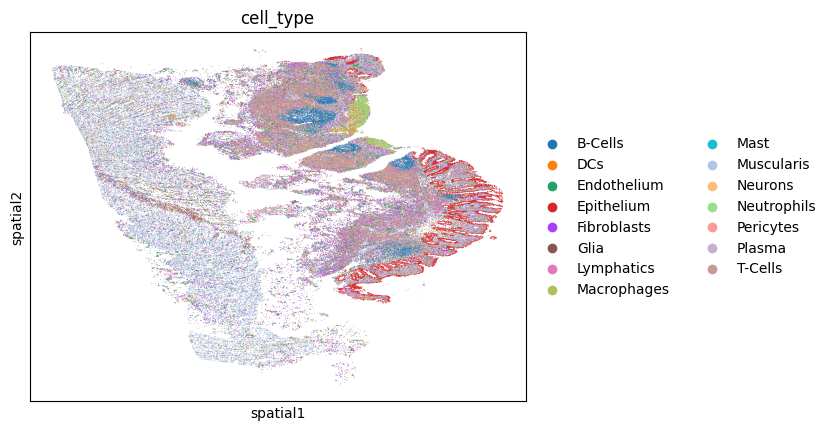

In [7]:
sc.pl.embedding(adata, basis="spatial", color=["cell_type"], wspace=0.4, s=1)

Use the chosen bandwidth based on this exploration to compute the final spatial connectivity matrix $W_{ij}$.

In [8]:
li.ut.spatial_neighbors(adata=adata, bandwidth=30)

#### Visualize proximity

/data/ddimitrov/repos/liana-py/src/liana/plotting/_connectivity_plot.py:38: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.


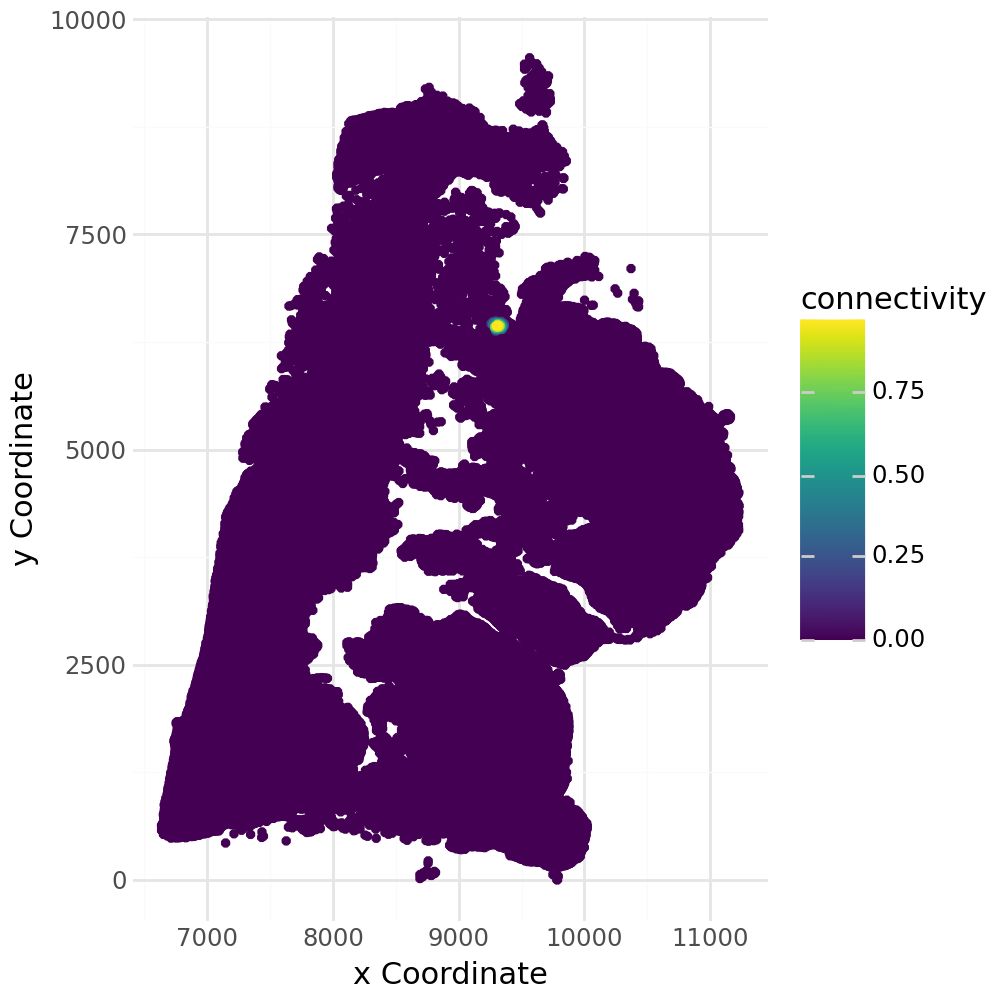

In [9]:
li.pl.connectivity(adata, idx=1000, size=1, figure_size=(5, 5))

### Find spatially variable genes (SVGs) using Morans'I

In [10]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [11]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
REG1A,0.463827,0.000000,1.599799e-07,0.000000
IL1B,0.458137,0.000000,1.599799e-07,0.000000
OLFM4,0.445979,0.000000,1.599799e-07,0.000000
HCAR3,0.439334,0.000000,1.599799e-07,0.000000
REG1B,0.433949,0.000000,1.599799e-07,0.000000
...,...,...,...,...
EIF5AL1,-0.000483,0.116225,1.599799e-07,0.130994
GRM2,-0.000540,0.090492,1.599799e-07,0.102832
ZHX3,-0.000541,0.090213,1.599799e-07,0.102560
INCA1,-0.000584,0.074006,1.599799e-07,0.084493


### Filter by spatially variable genes (SVGs)

In [12]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1629

In [13]:
adata = adata[:, svgs]

## Compute inflow score 

In [14]:
lrdata = li.mt.inflow(adata=adata, 
                resource_name='consensus', 
                groupby='cell_type',
                # obsm_key='compositions',
                use_raw=False,
                nz_prop=0.005
                )
lrdata.shape

/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/data/ddimitrov/repos/liana-py/src/liana/method/sp/_inflow.py:318: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


(191794, 5549)

### Optional: filter data to keep only spatially variable LR interaction

In [15]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [16]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

4703

In [17]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
Neutrophils^C3^ITGAX,0.383953,0.0,1.599799e-07,0.0
Neutrophils^CSF1^CSF3R,0.391347,0.0,1.599799e-07,0.0
Macrophages^LAMB3^CD44,0.393960,0.0,1.599799e-07,0.0
B-Cells^CD22^PTPRC,0.401462,0.0,1.599799e-07,0.0
B-Cells^ST6GAL1^CD22,0.411058,0.0,1.599799e-07,0.0
DCs^SPP1^CD44,0.421194,0.0,1.599799e-07,0.0
B-Cells^CXCL12^CXCR4,0.424790,0.0,1.599799e-07,0.0
Macrophages^SPP1^CD44,0.432970,0.0,1.599799e-07,0.0
B-Cells^C3^CD19,0.470334,0.0,1.599799e-07,0.0
B-Cells^CXCL14^CXCR4,0.471503,0.0,1.599799e-07,0.0


### Convert lrdata to muData

In [18]:
import scanpy as sc
import mudata as md
import anndata as an
import numpy as np
from tqdm import tqdm

from liana._constants import DefaultValues as V
from liana.method._pipe_utils._pre import _choose_mtx_rep
from liana._docs import d
from liana._logging import _logg


def split_to_mdata(
    adata,
    lr_sep = V.lr_sep,
    vars_per_cell = None,
    cells_per_var = V.min_cells,
    keep_view_vars = 10,
    keep_view_obs_prop = 0.1,
    use_raw = V.use_raw,
    layer = V.layer,
    verbose = V.verbose,
):
    """
    Split AnnData object into MultiData object by variable name prefixes.

    Args:
    ----------
    %(adata)s
    %(lr_sep)s
        Separator used in variable names to split views (e.g., 'ligand^receptor').
    vars_per_cell
        Minimum number of variables that should be present per cell (filtering within views).
    cells_per_var
        Minimum number of cells that should express each variable (filtering within views).
    keep_view_vars
        Minimum number of variables required for a view to be kept. Default is 10.
    keep_view_obs_prop
        Minimum proportion of original cells required for a view to be kept. Default is 0.1.
    %(use_raw)s
    %(layer)s
    %(verbose)s

    Returns
    -------
        MultiData: A new MultiData object with views split by variable name prefixes.
    """

    adata_dict = {}
    n_original_cells = adata.n_obs
    min_view_cells = int(n_original_cells * keep_view_obs_prop)
    
    # Extract views from variable name prefixes before the `lr_sep` separator
    views = adata.var.index.str.split(lr_sep, expand=True).get_level_values(0).unique().tolist()

    for view in tqdm(views, desc="Processing views", disable=not verbose):

        # Filter variables (genes) belonging to the current view
        var_filter = adata.var.index.str.startswith(f"{view}{lr_sep}")
        adata_mod = adata[:, var_filter].copy()
        
        # Get sparse matrix representation
        X = _choose_mtx_rep(adata_mod, use_raw=use_raw, layer=layer, verbose=False)

        # Filter by genes (cells_per_var): count non-zero elements per gene across cells
        if cells_per_var is not None:
            gene_counts = X.getnnz(axis=0)
            gene_mask = gene_counts >= cells_per_var
            X = X[:, gene_mask]
            adata_mod = adata_mod[:, gene_mask].copy()
        
        # Filter by cells (vars_per_cell): count non-zero elements per cell across genes
        if vars_per_cell is not None:
            cell_counts = X.getnnz(axis=1)
            cell_mask = cell_counts >= vars_per_cell
            X = X[cell_mask, :]
            adata_mod = adata_mod[cell_mask, :].copy()
        
        # Update X in adata_mod
        adata_mod.X = X

        # Check if view meets minimum requirements
        if adata_mod.n_vars >= keep_view_vars and adata_mod.n_obs >= min_view_cells:
            adata_dict[view] = adata_mod
            _logg(f"{view}: {adata_mod.n_obs} cells, {adata_mod.n_vars} vars after filtering.", verbose=verbose)
        else:
            _logg(f"{view} excluded: {adata_mod.n_obs} cells < {min_view_cells} or {adata_mod.n_vars} vars < {keep_view_vars}", level='warn', verbose=verbose)

    # Create MuData object with filtered views
    mdata = md.MuData(adata_dict)
    
    # Find intersecting observations
    intersecting_obs = adata.obs.index.intersection(mdata.obs.index)
    if len(intersecting_obs) > 0:
        # Subset adata to intersecting observations and copy obsm
        mdata.obsm = adata[intersecting_obs].obsm.copy()
        mdata.obs = adata[intersecting_obs].obs.copy()
        
    else:
        if verbose:
            _logg("No intersecting observations found between adata and mdata", level='warn', verbose=verbose)
    
    return mdata

In [19]:
# lrdata_path  = Path("../../data/MERFISH_mouse_brain/")
# adata = sc.read_h5ad(lrdata_path / "lrdata_C57BL6J_2.039.h5ad")

In [20]:
lrdata.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5823422 stored elements and shape (191794, 4703)>

In [21]:
# subset to random 20k cells
# lrdata = lrdata[lrdata.obs.sample(n=2000, random_state=42).index,:].copy()

In [22]:
sc.pp.filter_cells(lrdata, min_genes=20)

/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [23]:
lrdata

AnnData object with n_obs × n_vars = 100810 × 4703
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
    var: 'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
    uns: 'cell_type_colors', 'moranI'
    obsm: 'X_umap', 'spatial'
    obsp: 'spatial_connectivities'

/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


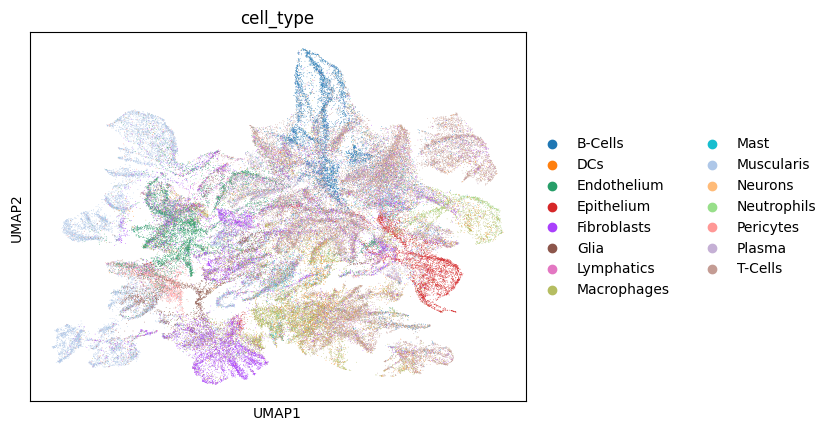

In [24]:
sc.pp.pca(lrdata)
sc.pp.neighbors(lrdata, use_rep='X_pca')
sc.tl.umap(lrdata, neighbors_key='neighbors')
sc.pl.umap(
    lrdata,
    color=["cell_type"],
    # Setting a smaller point size to get prevent overlap
    size=1,
)

In [25]:
mdata = split_to_mdata(lrdata,
               lr_sep="^",
               use_raw=False,
               layer=None,
               vars_per_cell = None,
               cells_per_var = V.min_cells,
               keep_view_vars = 10,
               keep_view_obs_prop = 0.1,
               verbose=True
               )

Processing views:   0%|          | 0/15 [00:00<?, ?it/s]B-Cells: 100810 cells, 295 vars after filtering.
Macrophages: 100810 cells, 357 vars after filtering.
Processing views:  13%|█▎        | 2/15 [00:00<00:01, 11.60it/s]DCs: 100810 cells, 353 vars after filtering.
Neutrophils: 100810 cells, 204 vars after filtering.
Processing views:  27%|██▋       | 4/15 [00:00<00:00, 12.07it/s]Lymphatics: 100810 cells, 329 vars after filtering.
Neurons: 100810 cells, 157 vars after filtering.
Processing views:  40%|████      | 6/15 [00:00<00:00, 12.20it/s]Fibroblasts: 100810 cells, 361 vars after filtering.
T-Cells: 100810 cells, 341 vars after filtering.
Processing views:  53%|█████▎    | 8/15 [00:00<00:00, 11.81it/s]Plasma: 100810 cells, 342 vars after filtering.
Muscularis: 100810 cells, 324 vars after filtering.
Processing views:  67%|██████▋   | 10/15 [00:00<00:00, 11.76it/s]Epithelium: 100810 cells, 286 vars after filtering.
Pericytes: 100810 cells, 329 vars after filtering.
Processing views:

In [26]:
mdata

MuData object with n_obs × n_vars = 100810 × 4644
  obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
  var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
  obsm:	'X_umap', 'spatial', 'X_pca'
  15 modalities
    B-Cells:	100810 x 295
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
      uns:	'cell_type_colors', 'moranI', 'pca', 'neighbors', 'umap'
      obsm:	'X_umap', 'spatial', 'X_pca'
      varm:	'PCs'
      obsp:	'spatial_connectivities', 'distances', 'connectivities'
    Macrophages:	100810 x 357
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
      uns:	'cell_type_colors', 'moranI', 'pca', 'neighbors', 'umap'
      obsm:	'X_umap', 'spatial', 'X_pca'
      varm:	'PCs'
      obsp:	'spatial_connectivities', 'distances', 'connectivities'
    DCs:	100810 x 353
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
      uns:	'cell_type_colors', 'moranI', 'pca', 'neighbors', 'umap'
      obsm:	'X_umap', 'spatial', 'X_pca'
      varm:	'PCs'
      obsp:	'spatial_connectivities', 'distances', 'connectivities'
    Neutrophils:	100810 x 204
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
      uns:	'cell_type_colors', 'moranI', 'pca', 'neighbors', 'umap'
      obsm:	'X_umap', 'spatial', 'X_pca'
      varm:	'PCs'
      obsp:	'spatial_connectivities', 'distances', 'connectivities'
    Lymphatics:	100810 x 329
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
      uns:	'cell_type_colors', 'moranI', 'pca', 'neighbors', 'umap'
      obsm:	'X_umap', 'spatial', 'X_pca'
      varm:	'PCs'
      obsp:	'spatial_connectivities', 'distances', 'connectivities'
    Neurons:	100810 x 157
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
      uns:	'cell_type_colors', 'moranI', 'pca', 'neighbors', 'umap'
      obsm:	'X_umap', 'spatial', 'X_pca'
      varm:	'PCs'
      obsp:	'spatial_connectivities', 'distances', 'connectivities'
    Fibroblasts:	100810 x 361
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
      uns:	'cell_type_colors', 'moranI', 'pca', 'neighbors', 'umap'
      obsm:	'X_umap', 'spatial', 'X_pca'
      varm:	'PCs'
      obsp:	'spatial_connectivities', 'distances', 'connectivities'
    T-Cells:	100810 x 341
      obs:	'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
      uns:	'cell_type_colors', 'moranI', 'pca', 'neighbors', 'umap'
      obsm:	'X_umap', 'spatial', 'X_pca'
      varm:	'PCs'
      o

# Run MOFA-Flex

In [27]:
import mudata as md
import mofaflex as mfl

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [28]:
# mdata = md.read_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

In [29]:
data_opts = mfl.DataOptions(plot_data_overview=False) # , covariates_obs_key='spatial'


model_opts = mfl.ModelOptions(
        n_factors=20,
        factor_prior="Normal",
        likelihoods="Normal",
        weight_prior="Horseshoe",
        nonnegative_factors=False,
        nonnegative_weights=False,
        init_factors='random',
        init_scale=0.1
    )


training_opts = mfl.TrainingOptions(
        batch_size=10_000,
        n_particles=1,
        lr=0.005,
        max_epochs=2000,
        save_path=str("model_sns_gp_C57BL6J_2.039.hdf5"),
        early_stopper_patience=100,
        device='cuda'
    )

In [30]:
mfl.presets.MOFA

(ModelOptions(n_factors=10, weight_prior='Horseshoe', factor_prior='Normal', likelihoods='Normal', nonnegative_weights=False, guiding_vars_likelihoods='Normal', guiding_vars_scales=1.0, nonnegative_factors=False, annotation_confidence=0.99, init_factors='random', init_scale=0.1),
 TrainingOptions(device=device(type='cuda'), batch_size=0, max_epochs=10000, n_particles=1, lr=0.05, early_stopper_patience=100, save_path=None, mofa_compat=False, seed=None, num_workers=0, pin_memory=False))

In [31]:
model = mfl.MOFAFLEX(
    mdata,
    data_opts,
    model_opts,
    training_opts,
)

Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.

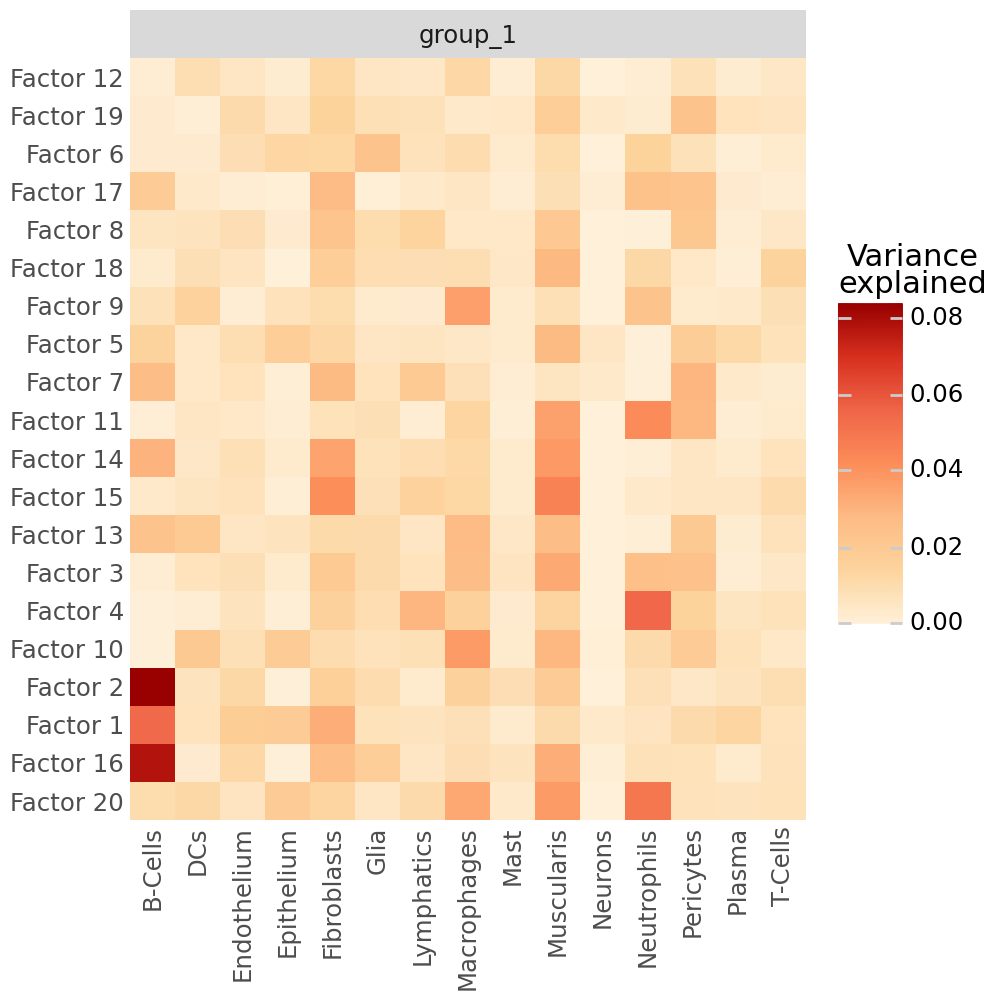

In [32]:
mfl.pl.variance_explained(model, figsize=(5, 5))

In [33]:
model

# Model Overview

In [34]:
#Load mofa model
# model = mfl.MOFAFLEX.load("model_sns_gp_C57BL6J_2.039.hdf5")

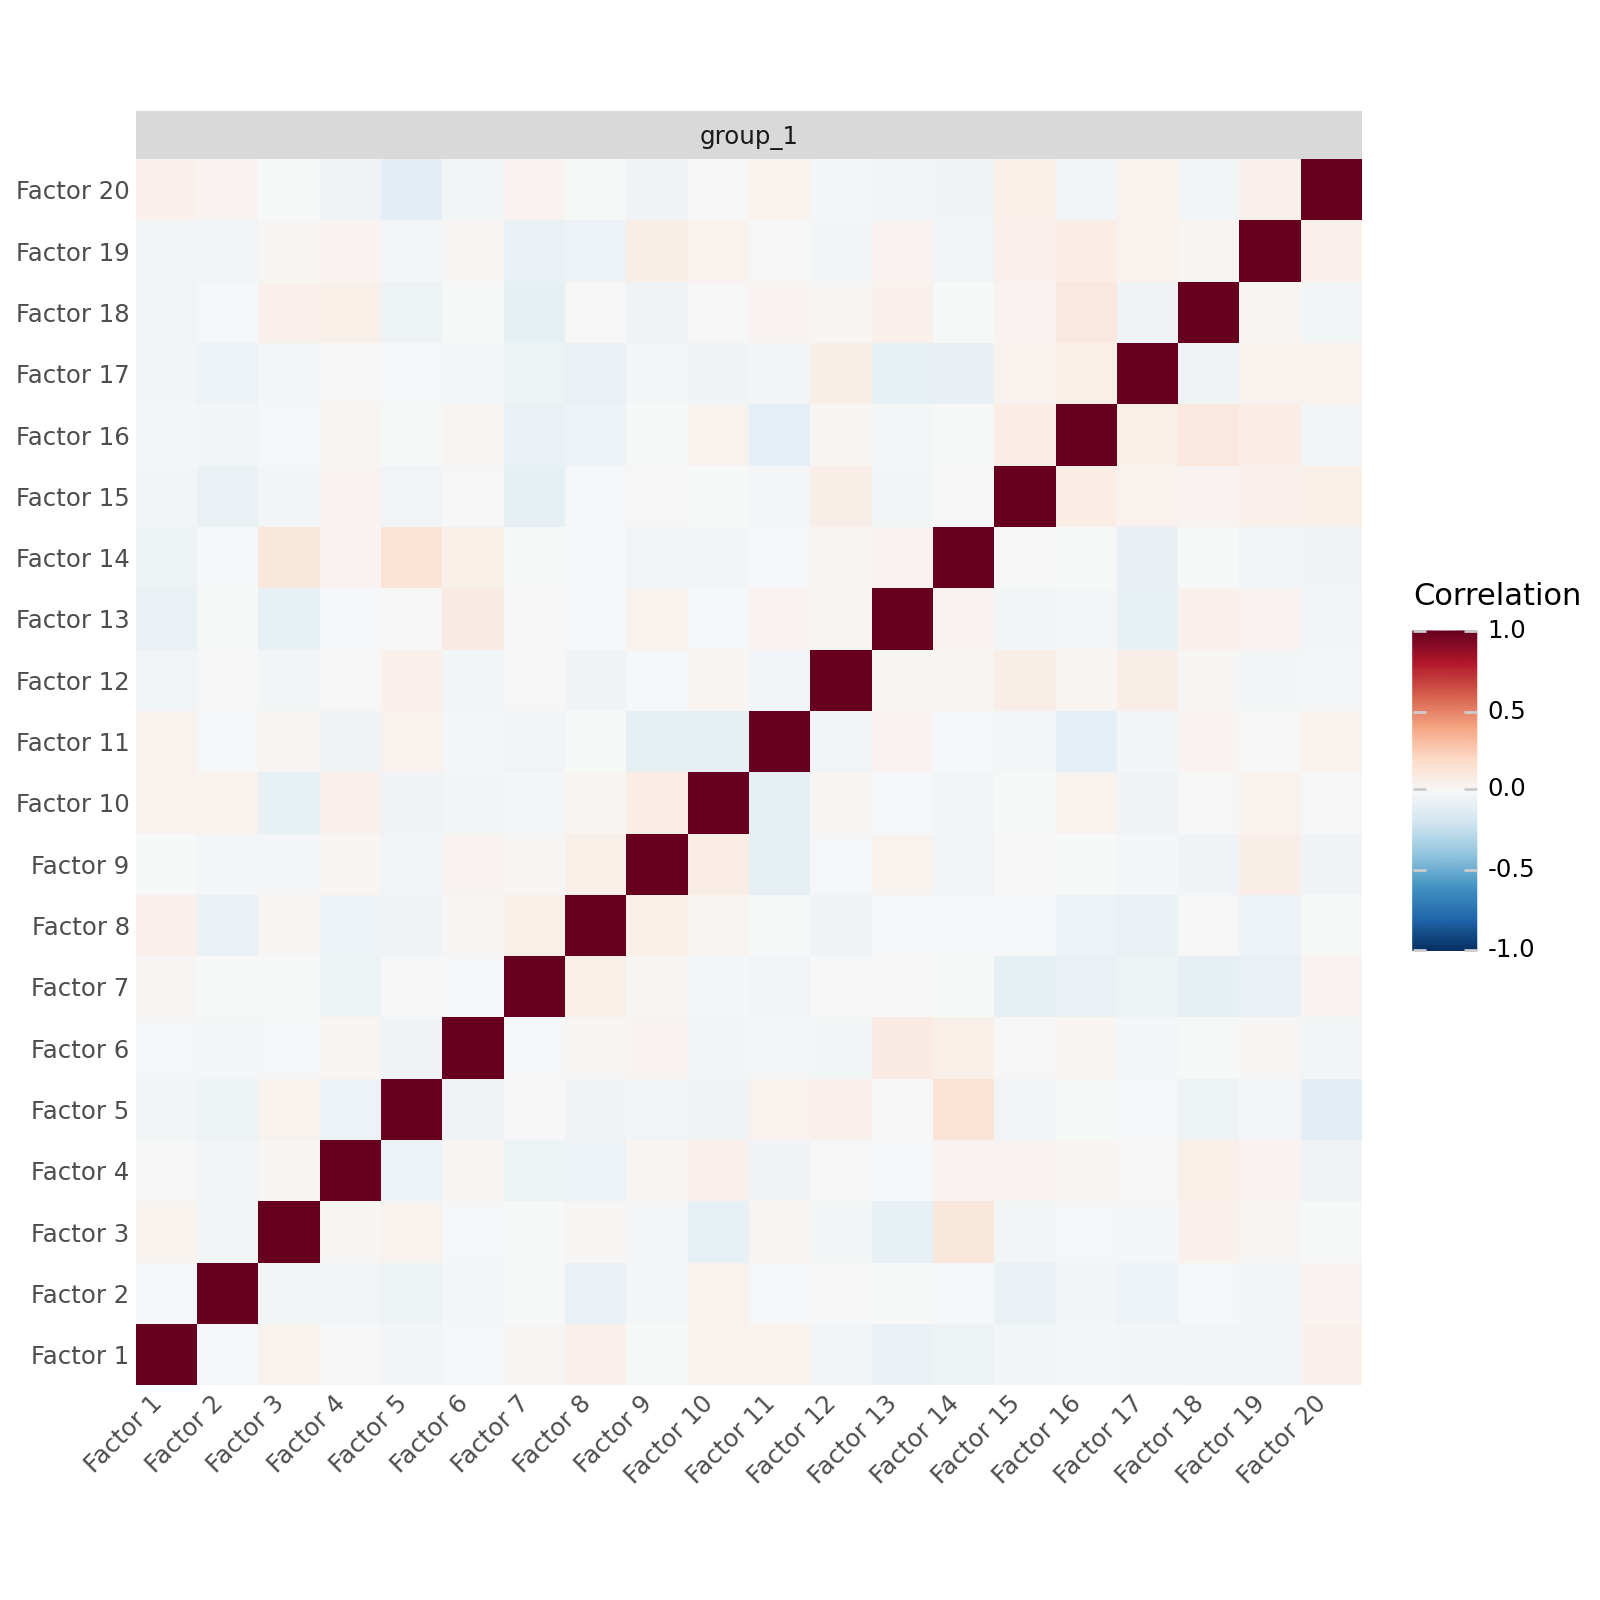

In [35]:
#Factor correlation
mfl.pl.factor_correlation(model)

In [36]:
def filter_factors(model, r2_thresh=0.99):
    r2_df = model.get_r2()["group_1"]
    r2_sorted = r2_df.sum(axis=1).sort_values(ascending=False)

    if r2_thresh < 1.0:
        r2_thresh = (r2_sorted.cumsum() / r2_sorted.sum() < r2_thresh).sum() + 1

    return r2_sorted.iloc[: int(r2_thresh)].index

In [37]:
factor_adata = model.get_factors("anndata")["group_1"][:, filter_factors(model)]

In [38]:
factor_adata

View of AnnData object with n_obs × n_vars = 100810 × 20
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'

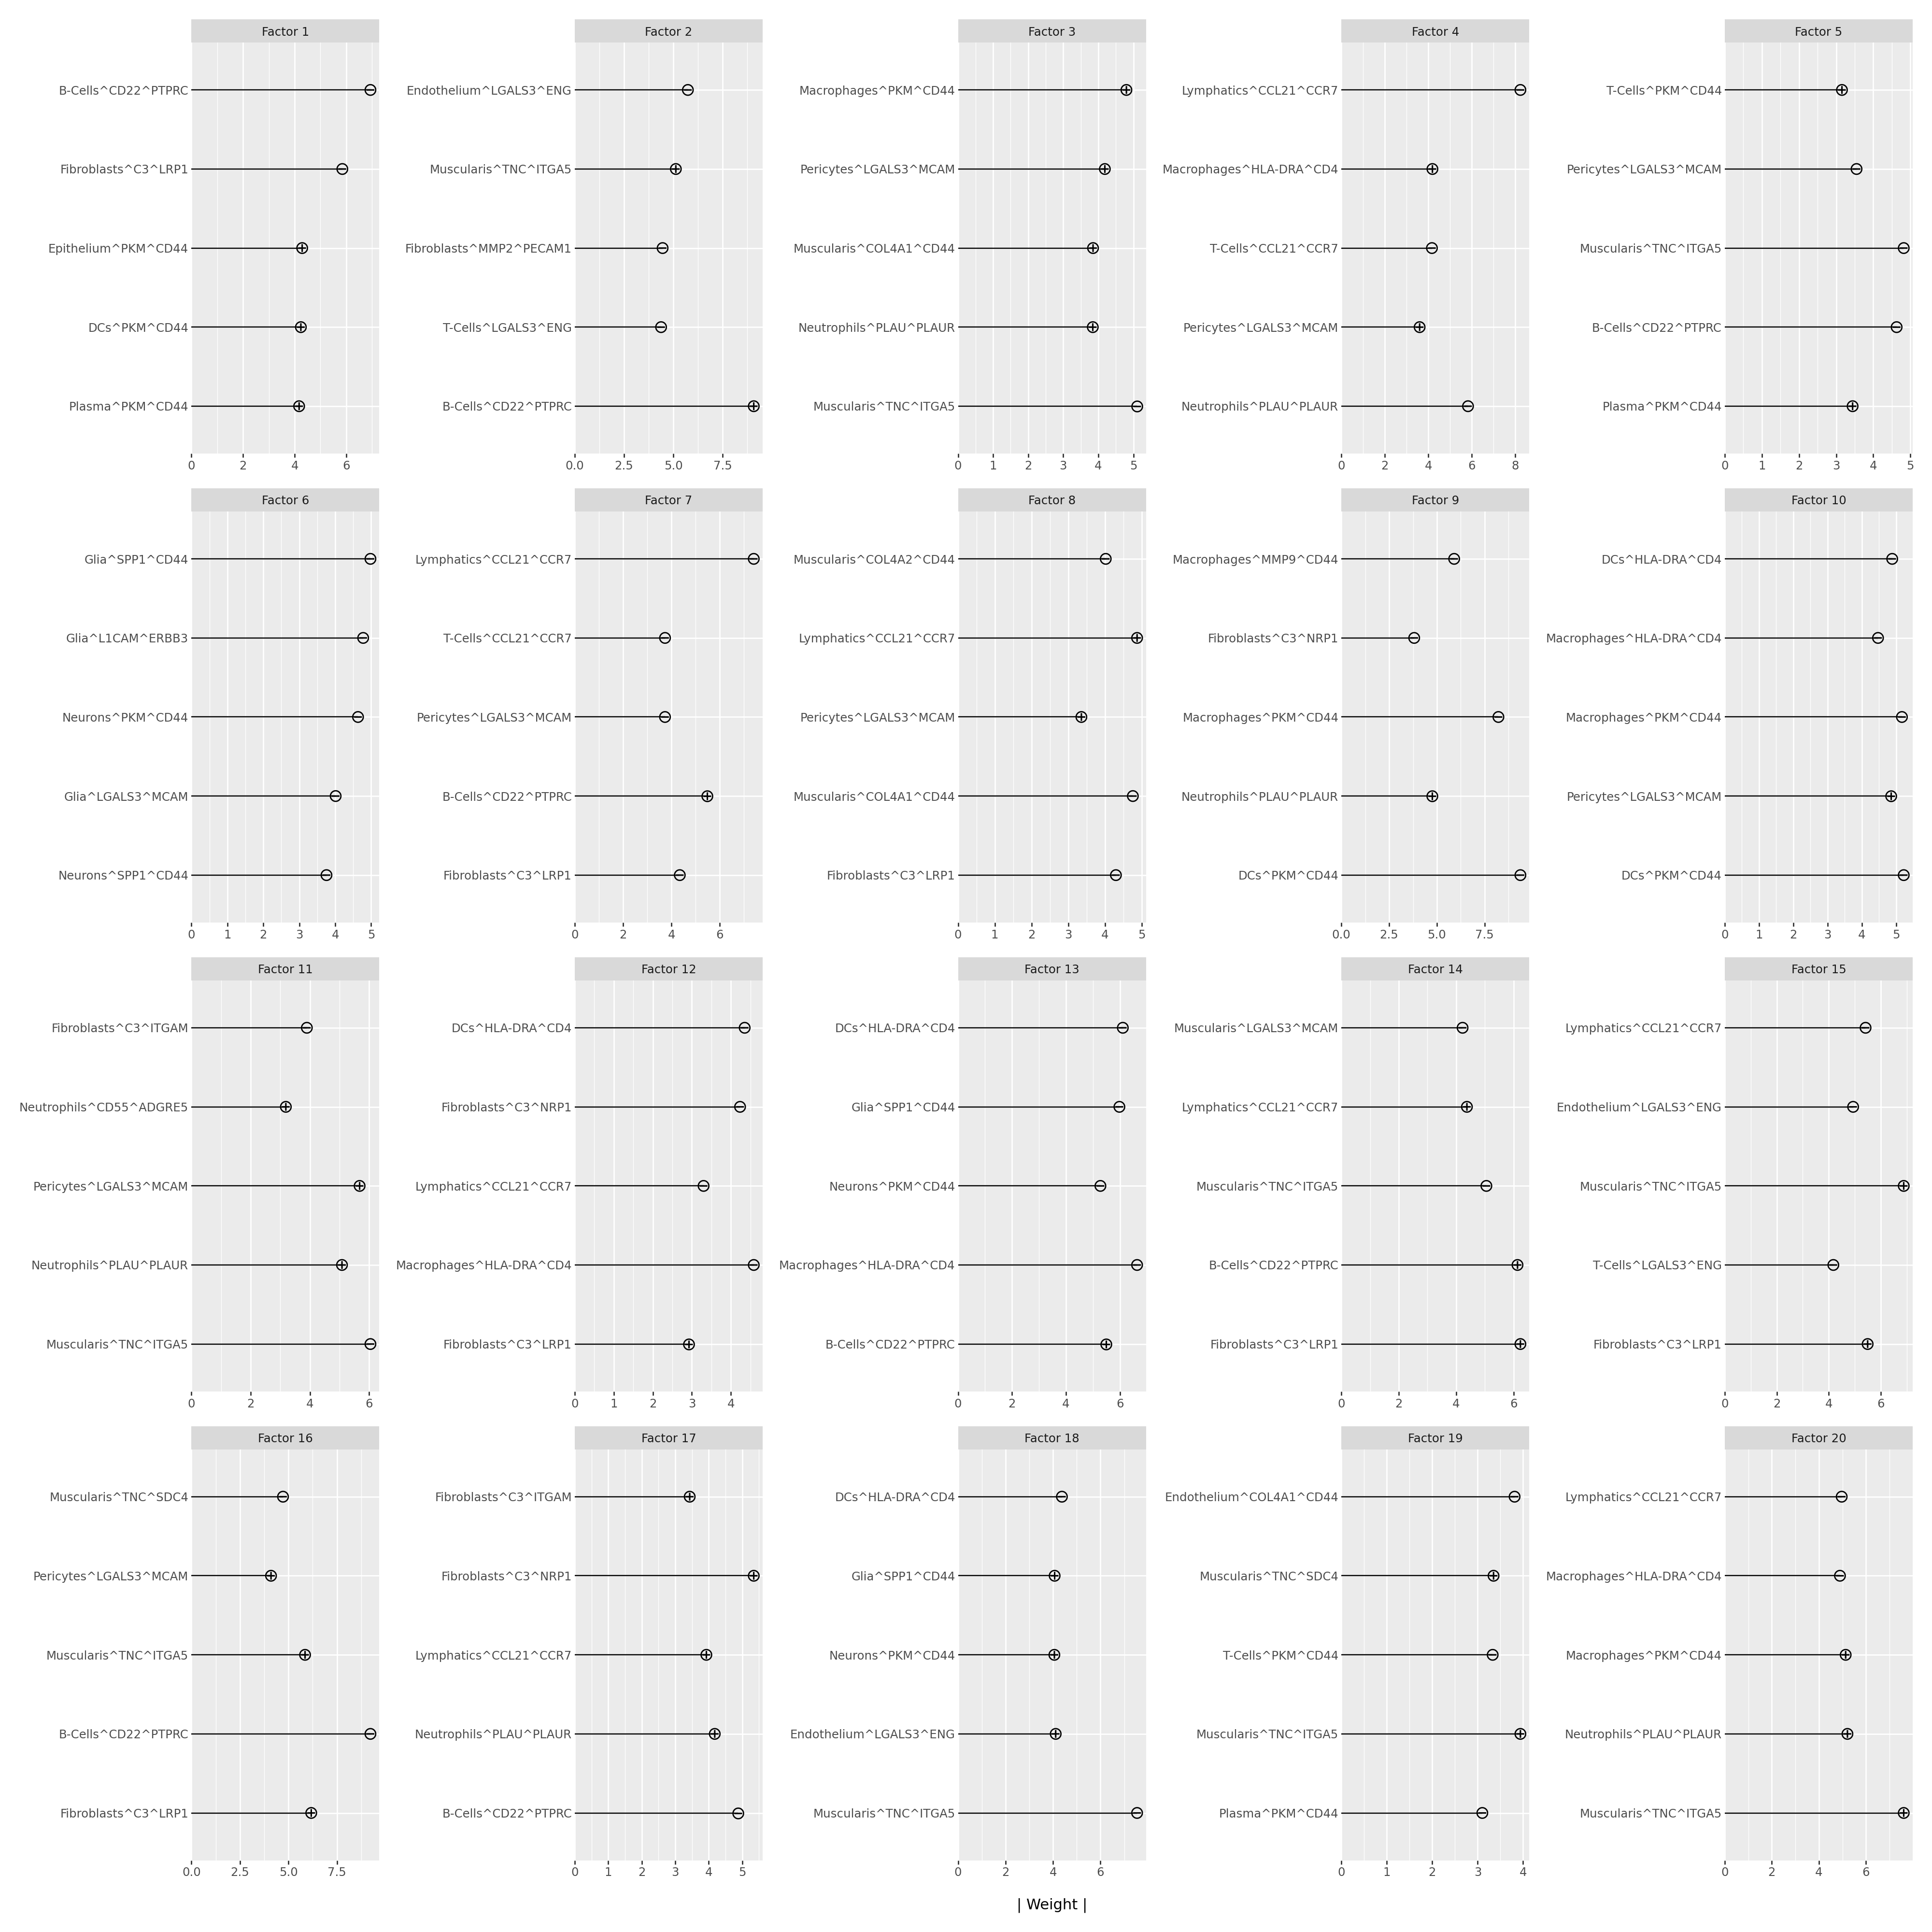

In [39]:
mfl.pl.top_weights(model, n_features=5, factors=None, figsize=(20, 20), nrow=None, ncol=None)

In [40]:
mdata.obsm['X_MOFA'] = factor_adata.X

In [41]:
mdata.obsm['X_MOFA']

ArrayView([[-0.28415707,  0.6773715 , -0.81209826, ...,  0.3910334 ,
             0.12439714,  0.46058092],
           [-0.61132926, -0.4369733 , -1.2397076 , ..., -0.42654717,
            -0.76580113, -0.4392866 ],
           [-0.16524675,  0.96937555,  0.3367171 , ..., -1.3674524 ,
             0.1790258 , -0.29012808],
           ...,
           [ 0.25870162,  0.26418638,  0.07441052, ...,  0.09432422,
             0.17946535,  0.00378067],
           [ 0.21926716,  0.1708712 ,  0.10099361, ...,  0.13051799,
             0.1414344 ,  0.01369295],
           [ 0.00430432,  0.07669383,  0.05000239, ..., -0.08658582,
             0.09461824,  0.05119826]], shape=(100810, 20), dtype=float32)

In [42]:
sc.pp.neighbors(factor_adata, use_rep='X')

In [43]:
factor_adata

AnnData object with n_obs × n_vars = 100810 × 20
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
    uns: 'neighbors'
    obsp: 'distances', 'connectivities'

In [44]:
sc.tl.umap(factor_adata, neighbors_key='neighbors')

In [45]:
factor_adata.obs['factor_x'] = factor_adata.X[:,12]

... storing 'x' as categorical
... storing 'y' as categorical
... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical
... storing 'CellAnnotation.Level0' as categorical
... storing 'nCount_XENIUM_clean' as categorical
... storing 'nFeature_XENIUM_clean' as categorical
... storing 'cell_type' as categorical
... storing 'n_genes' as categorical


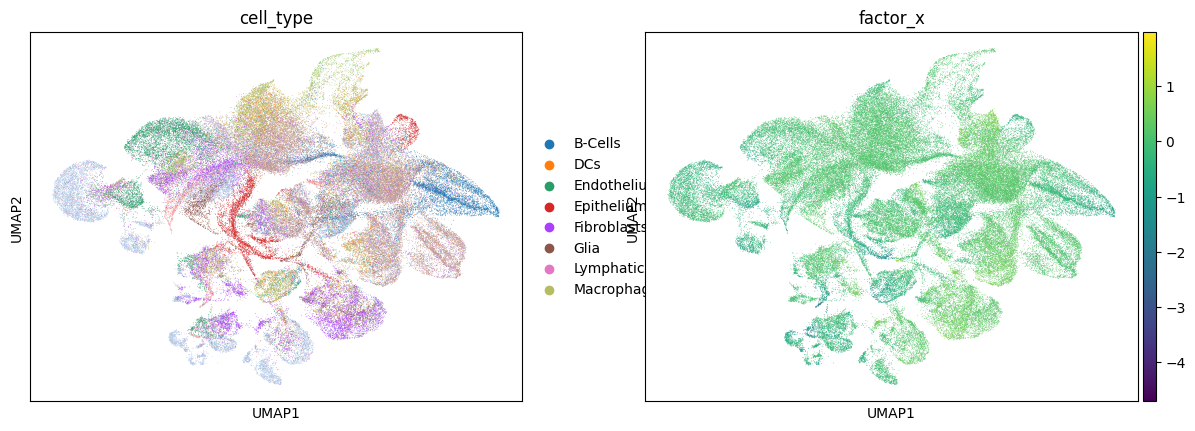

In [46]:
sc.pl.umap(
    factor_adata,
    color=["cell_type", 'factor_x'],
    # Setting a smaller point size to get prevent overlap
    size=1,
)

In [47]:
sc.tl.leiden(factor_adata, resolution=0.1)

/tmp/ipykernel_1916902/1965645390.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


In [48]:
factor_adata.obsm['spatial'] = mdata.obsm['spatial']

/tmp/ipykernel_1916902/3272011984.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


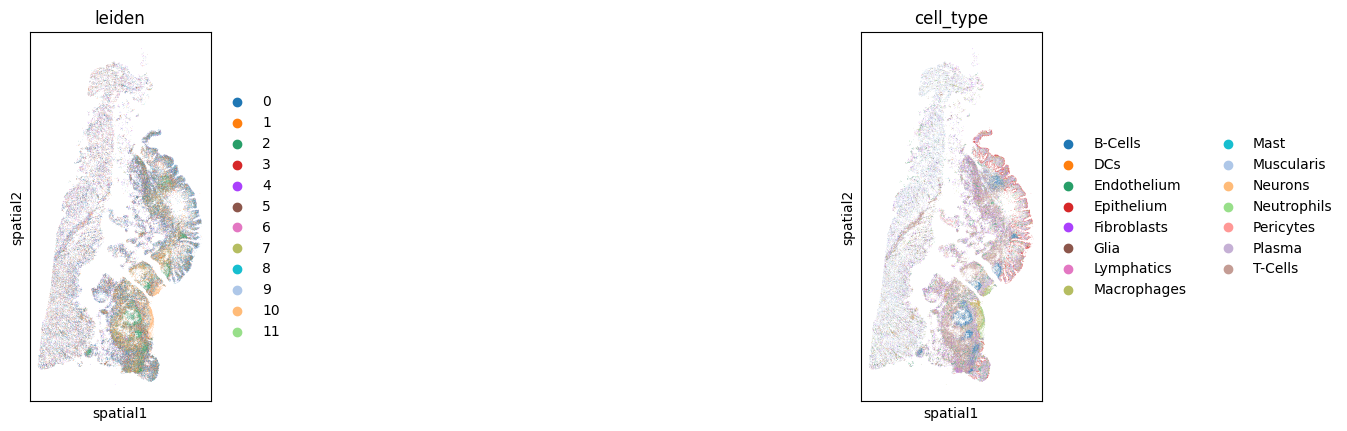

In [49]:
sc.pl.spatial(factor_adata, basis="spatial", color=["leiden", "cell_type"], wspace=0.4, spot_size=10)

In [50]:
factor_adata.obs = mdata.obs

We will run simple Random forest model to find whether we can predict brain regions from latent factors or not.

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [52]:
X = factor_adata.X  
y = factor_adata.obs["cell_type"].values
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

In [54]:
rf = RandomForestClassifier(
    n_estimators=300,
#    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
# Evaluation
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.7058823529411765
              precision    recall  f1-score   support

     B-Cells       0.74      0.76      0.75      1290
         DCs       0.38      0.01      0.02       644
 Endothelium       0.79      0.86      0.82      1397
  Epithelium       0.87      0.95      0.91       795
 Fibroblasts       0.63      0.62      0.62      2513
        Glia       0.81      0.69      0.74       759
  Lymphatics       0.66      0.14      0.23       443
 Macrophages       0.65      0.71      0.68      2638
        Mast       0.42      0.15      0.22       342
  Muscularis       0.77      0.83      0.80      2488
     Neurons       1.00      0.29      0.45        17
 Neutrophils       0.54      0.32      0.40       111
   Pericytes       0.63      0.46      0.53       620
      Plasma       0.60      0.54      0.57      1281
     T-Cells       0.71      0.86      0.77      4824

    accuracy                           0.71     20162
   macro avg       0.68      0.55      0.57     201

In [56]:
from sklearn.metrics import roc_auc_score

y_proba = rf.predict_proba(X_test)

auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)

auc_weighted = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC (macro):   ", auc_macro)
print("ROC-AUC (weighted):", auc_weighted)

ROC-AUC (macro):    0.9324209828859975
ROC-AUC (weighted): 0.9370650689561398


In [57]:
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

per_class_auc = roc_auc_score(
    y_test_bin,
    y_proba,
    average=None
)

for cls, auc in zip(le.classes_, per_class_auc):
    print(f"{cls}: AUC = {auc:.3f}")


B-Cells: AUC = 0.970
DCs: AUC = 0.824
Endothelium: AUC = 0.982
Epithelium: AUC = 0.998
Fibroblasts: AUC = 0.887
Glia: AUC = 0.973
Lymphatics: AUC = 0.841
Macrophages: AUC = 0.933
Mast: AUC = 0.901
Muscularis: AUC = 0.974
Neurons: AUC = 0.965
Neutrophils: AUC = 0.958
Pericytes: AUC = 0.925
Plasma: AUC = 0.914
T-Cells: AUC = 0.943


### Confusion Matrix

In [58]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

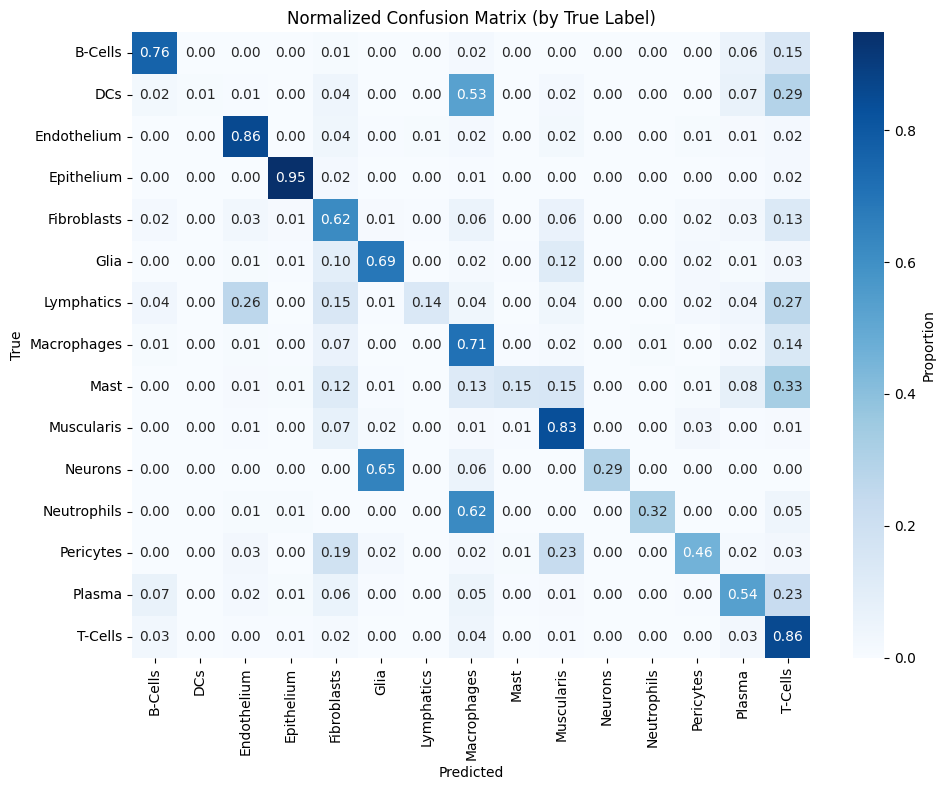

In [60]:
# Normalized confusion matrix (shows which labels are confused)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cbar_kws={'label': 'Proportion'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (by True Label)')
plt.tight_layout()
plt.show()

----

## MOFA

In [61]:
import muon as mu

/data/ddimitrov/software/miniforge3/envs/liana313/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead


In [62]:
mu.tl.mofa(mdata,
           use_obs='union',
           convergence_mode='medium',
           n_factors=20,
           seed=1337,
           outfile='models/mofacellx.h5ad',
        #    use_var='highly_variable'
           )


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='B-Cells' group='group1' with N=100810 samples and D=295 features...
Loaded view='Macrophages' group='group1' with N=100810 samples and D=357 features...
Loaded view='DCs' group='group1' with N=100810 samples and D=353 features...
Loaded view='Neutrophils' group='group1' with N=100810 samples and D=204 features...
Loaded view='Lymphatics' group='group1' with N=100810 sample

In [63]:
adata = sc.AnnData(obs = mdata.obs, obsm=mdata.obsm)

In [64]:
import scanpy as sc

In [65]:

sc.pp.neighbors(adata, use_rep='X_mofa')
sc.tl.umap(adata)

In [66]:
adata.obs

,cell,x,y,SAMPLE,TYPE,LOCATION,CellAnnotation.Level3,CellAnnotation.Level0,nCount_XENIUM_clean,nFeature_XENIUM_clean,cell_type,n_genes
CR0f5fda56f-1005,CR0f5fda56f-1005,9256.619126,15645.616528,RUN1_SLIDE2_S6,ULCER,ILEUM,Monocytes CCR2+,Macrophages,200.0,176,Macrophages,26
CR0f5fda56f-1007,CR0f5fda56f-1007,8988.678413,15922.350740,RUN1_SLIDE2_S6,ULCER,ILEUM,Stromal 3,Fibroblasts,378.0,256,Fibroblasts,43
CR0f5fda56f-101,CR0f5fda56f-101,9155.494838,14869.435363,RUN1_SLIDE2_S6,ULCER,ILEUM,Extraganglionic Glia,Glia,462.0,333,Glia,50
CR0f5fda56f-1014,CR0f5fda56f-1014,9024.010598,15876.458288,RUN1_SLIDE2_S6,ULCER,ILEUM,Stromal 3,Fibroblasts,97.0,73,Fibroblasts,23
CR0f5fda56f-1015,CR0f5fda56f-1015,9262.321313,15647.175789,RUN1_SLIDE2_S6,ULCER,ILEUM,Stromal 3,Fibroblasts,414.0,301,Fibroblasts,33
...,...,...,...,...,...,...,...,...,...,...,...,...
CRf3c5992a7-991,CRf3c5992a7-991,7651.243894,19844.387213,RUN1_SLIDE2_S6,ULCER,ILEUM,Stromal 3,Fibroblasts,73.0,59,Fibroblasts,28
CRf3c5992a7-9927,CRf3c5992a7-9927,7591.136991,20505.229893,RUN1_SLIDE2_S6,ULCER,ILEUM,Pericytes,Pericytes,85.0,69,Pericytes,32
CRf3c5992a7-994,CRf3c5992a7-994,7557.601128,19935.729311,RUN1_SLIDE2_S6,ULCER,ILEUM,Inner Muscularis,Muscularis,169.0,134,Muscularis,35
CRf3c5992a7-998,CRf3c5992a7-998,7548.652679,19948.950000,RUN1_SLIDE2_S6,ULCER,ILEUM,Pericytes,Pericytes,68.0,57,Pericytes,24


... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical


... storing 'CellAnnotation.Level0' as categorical
... storing 'cell_type' as categorical


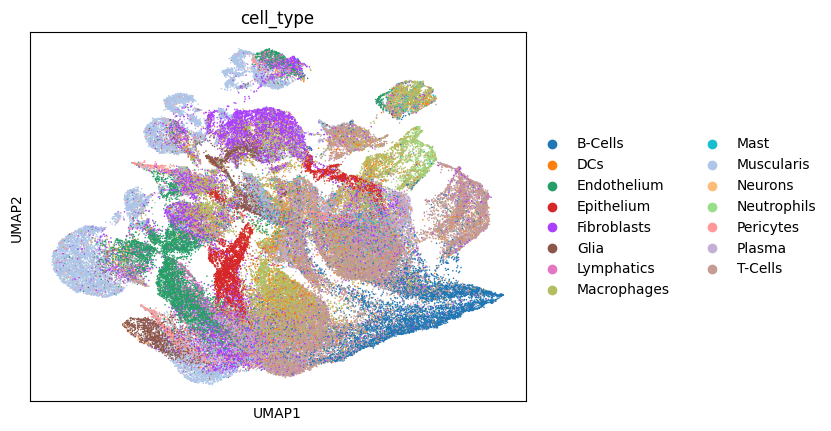

In [67]:
sc.pl.umap(adata, color=['cell_type'], s=5)

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [69]:
X = adata.obsm["X_mofa"]  
y = adata.obs["cell_type"].values
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

In [71]:
rf = RandomForestClassifier(
    n_estimators=300,
#    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [72]:
# Evaluation
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.7196210693383593
              precision    recall  f1-score   support

     B-Cells       0.75      0.77      0.76      1290
         DCs       0.32      0.01      0.02       644
 Endothelium       0.81      0.85      0.83      1397
  Epithelium       0.89      0.95      0.92       795
 Fibroblasts       0.64      0.64      0.64      2513
        Glia       0.79      0.73      0.76       759
  Lymphatics       0.63      0.19      0.29       443
 Macrophages       0.66      0.74      0.70      2638
        Mast       0.40      0.14      0.21       342
  Muscularis       0.79      0.84      0.82      2488
     Neurons       1.00      0.06      0.11        17
 Neutrophils       0.56      0.32      0.40       111
   Pericytes       0.62      0.46      0.53       620
      Plasma       0.62      0.52      0.57      1281
     T-Cells       0.73      0.88      0.79      4824

    accuracy                           0.72     20162
   macro avg       0.68      0.54      0.56     201

In [73]:
from sklearn.metrics import roc_auc_score

y_proba = rf.predict_proba(X_test)

auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)

auc_weighted = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC (macro):   ", auc_macro)
print("ROC-AUC (weighted):", auc_weighted)

ROC-AUC (macro):    0.9375059592045666
ROC-AUC (weighted): 0.9432873192347138


In [74]:
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

per_class_auc = roc_auc_score(
    y_test_bin,
    y_proba,
    average=None
)

for cls, auc in zip(le.classes_, per_class_auc):
    print(f"{cls}: AUC = {auc:.3f}")


B-Cells: AUC = 0.972
DCs: AUC = 0.842
Endothelium: AUC = 0.980
Epithelium: AUC = 0.999
Fibroblasts: AUC = 0.897
Glia: AUC = 0.976
Lymphatics: AUC = 0.860
Macrophages: AUC = 0.940
Mast: AUC = 0.904
Muscularis: AUC = 0.976
Neurons: AUC = 0.963
Neutrophils: AUC = 0.957
Pericytes: AUC = 0.927
Plasma: AUC = 0.916
T-Cells: AUC = 0.952


In [75]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

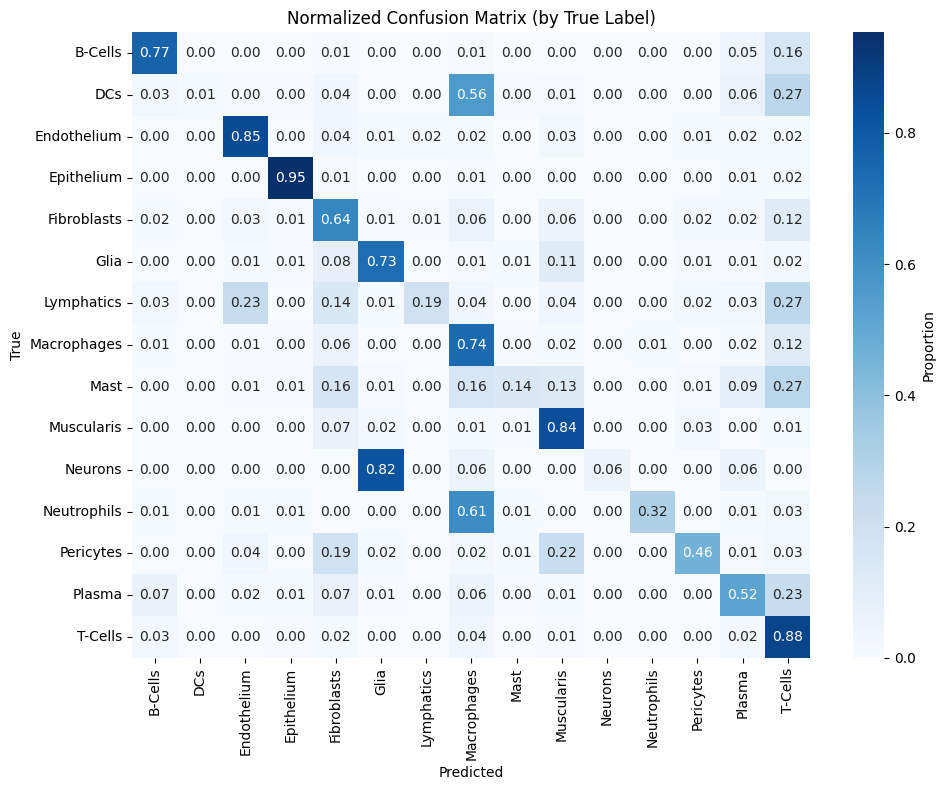

In [76]:
# Normalized confusion matrix (shows which labels are confused)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cbar_kws={'label': 'Proportion'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (by True Label)')
plt.tight_layout()
plt.show()